<a href="https://colab.research.google.com/github/Michael2004-ukpeh/ml-playground/blob/master/Logistic_Regression_Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Import Data

In [ ]:
# Google sheet.

google_sheet_id = '1fUWevh79VD3-8YzCZU-uUC1_LJfif5Y7_eX9dkUOe_o'

url = f'https://docs.google.com/spreadsheets/d/{google_sheet_id}/export?format=csv'

try:

    df = pd.read_csv(url)

    print("Google Sheet data loaded successfully:")

    display(df.head())

except Exception as e:

    print(f"Error loading Google Sheet: {e}")

Google Sheet data loaded successfully:


,x1,x2,x3,label
0,-0.332727,-0.696181,-0.286767,0
1,-1.510220,-1.375861,-1.197257,0
2,-1.256076,-1.228764,-1.785996,0
3,-0.772276,-0.409598,-0.267973,0
4,-1.346263,0.112805,0.612268,0


In [ ]:
df

,x1,x2,x3,label
0,-0.332727,-0.696181,-0.286767,0
1,-1.510220,-1.375861,-1.197257,0
2,-1.256076,-1.228764,-1.785996,0
3,-0.772276,-0.409598,-0.267973,0
4,-1.346263,0.112805,0.612268,0
...,...,...,...,...
195,-0.603475,-0.006417,-0.057825,0
196,-1.037773,-0.904611,-0.256521,0
197,0.686458,0.394530,0.191661,1
198,-1.183910,-0.943287,-0.645391,0


## Normalize given independent data


In [ ]:
x1 = df['x1'].values
x2 = df['x2'].values
x3 = df['x3'].values
Y = df['label'].values

X1 = (x1 - np.min(x1))/(np.max(x1)-np.min(x1))
X2 = (x2 - np.min(x2))/(np.max(x2)-np.min(x2))
X3=  (x3 - np.min(x3))/(np.max(x3)-np.min(x3))
display(X1,X2,X3)

array([0.47570229, 0.21354269, 0.27012591, 0.37784014, 0.25004652,
       0.59779126, 0.69907808, 0.52047135, 0.60295755, 0.40982451,
       0.81898612, 0.75911086, 0.27514396, 0.57978797, 0.46565213,
       0.71555382, 0.35674807, 0.60623601, 0.37213904, 0.69300878,
       0.56845369, 0.93041683, 0.66558733, 0.7940627 , 0.53661777,
       0.37590998, 0.35841226, 0.56892108, 0.72198975, 0.47005378,
       0.56937186, 0.5014774 , 0.5120378 , 0.45859709, 0.54430958,
       0.63140092, 0.38476846, 0.69802199, 0.61063924, 0.91775521,
       0.39688933, 1.        , 0.70740194, 0.52878076, 0.74870507,
       0.1588366 , 0.30051943, 0.16907598, 0.4917655 , 0.87235775,
       0.48965125, 0.48705347, 0.14868971, 0.38395414, 0.30602182,
       0.64014151, 0.48797683, 0.72560272, 0.56214163, 0.39055634,
       0.29547953, 0.47537393, 0.40191087, 0.86422238, 0.41599069,
       0.40996773, 0.46578253, 0.58443488, 0.77795957, 0.70477976,
       0.58106901, 0.43673405, 0.65777238, 0.61594188, 0.25585

array([0.36403766, 0.21362504, 0.24617758, 0.42745815, 0.54306559,
       0.58425223, 0.56065958, 0.67115226, 0.71821201, 0.44555567,
       0.69347544, 0.84875362, 0.51957668, 0.48462589, 0.64238288,
       0.57724034, 0.37578882, 0.53477885, 0.39120914, 0.51948855,
       0.69346178, 0.6881655 , 0.53346977, 0.54859899, 0.75970758,
       0.37219034, 0.46177859, 0.52189951, 0.60488363, 0.39814851,
       0.57552879, 0.68273454, 0.46343158, 0.55947267, 0.57932288,
       0.47234587, 0.60348973, 0.34456464, 0.5685839 , 0.73566319,
       0.22698942, 0.66349985, 0.70066617, 0.57563351, 0.81821821,
       0.19974041, 0.29988643, 0.19069392, 0.57602414, 0.7837626 ,
       0.52542059, 0.53027958, 0.23188668, 0.29823283, 0.18549337,
       0.31562852, 0.61388182, 0.6599287 , 0.48209583, 0.01053506,
       0.44404569, 0.35983292, 0.48025838, 0.75695077, 0.42758155,
       0.40328427, 0.44908288, 0.35382222, 0.7403734 , 0.14301875,
       0.36046055, 0.31909124, 0.70734859, 0.70031591, 0.36726

array([0.43118723, 0.26743285, 0.1615463 , 0.4345673 , 0.59288119,
       0.66850162, 0.77901934, 0.48563661, 0.53520541, 0.47594178,
       0.40236715, 0.54631871, 0.60932216, 0.38706468, 0.5021023 ,
       0.6545014 , 0.5998671 , 0.61547437, 0.22357123, 0.51663721,
       0.55359683, 0.61433571, 0.40693468, 0.5752279 , 0.29613664,
       0.3436475 , 0.64957026, 0.28153909, 0.66935675, 0.49087167,
       0.36537102, 0.54325332, 0.41330057, 0.64271211, 0.60687866,
       0.24874945, 0.4161161 , 0.52509624, 0.48353335, 0.56865866,
       0.4713055 , 0.68162259, 0.68866618, 0.70512487, 0.58482693,
       0.31279337, 0.47681359, 0.43556637, 0.34831034, 0.64148089,
       0.40013681, 0.40727629, 0.13215478, 0.48697396, 0.39901924,
       0.37700694, 0.57451018, 0.62077314, 0.36378836, 0.33352077,
       0.4476776 , 0.44246608, 0.40207437, 0.77119723, 0.56890248,
       0.50873123, 0.58647835, 0.3150957 , 0.7898068 , 0.42493843,
       0.30689098, 0.42596725, 0.61432316, 0.22182248, 0.51931

# Utility and Training functions

In [ ]:
# Loss Function
def binary_cr_entropy(Y, Y_pred, l2, w):
  eps = 1e-12   # eps (epsilon) is a very low value used to avoid divide-by-zero or log of zero errors.
  return -np.mean(Y*np.log(Y_pred + eps) + (1-Y)*np.log(1-Y_pred + eps)) + 0.5 * l2 * np.sum(w**2)

In [ ]:
# Probability function
def sigmoid(z):
  # Where z = m1*X1 + m2*X2 + m3*X3 + c
  return 1/(1+ np.exp(-z))

# vectorized gradient descent

In [ ]:
# Gradient descent
def gradient_change(X, Y, N, l2, w):
  # Sigmoid function calculates the probability
  return X.T.dot(sigmoid(X.dot(w)) - Y)/N + l2*w




# Let's train
- Calculate prediction based on sigmoid function
- Calculate cost based on binary cross entropy
- Calculate gradients of parameters
- Finetune parameters using gradient decent




In [ ]:
def train(X, Y, w, lr, epochs,l2,  history):
  """
  X: (N, d) input features (should include bias column if you want bias in weights)
  y: (N,) binary labels 0/1
  """
  N, d = X.shape
  # w = np.zeros(d)
  for i in range(epochs):
    # Calculate prediction
    Y_pred = sigmoid(X.dot(w))
    # Calculate cost
    cost = binary_cr_entropy(Y, Y_pred, l2, w)

    # Caculate gradient
    gradient = gradient_change(X, Y, N, l2, w)

    # Update parameters
    w -= lr * gradient
    # Track hyperparameters

    history['err_arr'].append(cost)

    history['m1_arr'].append(w[0])
    history['m2_arr'].append(w[1])
    history['m3_arr'].append(w[2])
    history['c_arr'].append(w[3])

    print(f"Epoch {i} :Binary Cross Entropy = {cost}\n ")
  print(f"Final parameters: m1 = {w[0]}, m2 = {w[1]}, m3 = {w[2]}, c = {w[3]}")
  return w[0], w[1], w[2], w[3]

Train with initial values of coefficients

In [ ]:

lr = 0.1
epochs = 500000
l2 = 0.0


history = {
    'm1_arr': [],
    'm2_arr': [],
    'm3_arr': [],
    'c_arr': [],
    'err_arr': []
}
bias = np.ones((X1.shape[0], 1))
X = np.column_stack((bias,X1,X2,X3))
w = np.zeros(X.shape[1])
m1, m2, m3, c = train(X,Y,w,lr,epochs,l2,history)

Streaming output truncated to the last 5000 lines.
 
Epoch 497501 :Binary Cross Entropy = 0.06178966072669912
 
Epoch 497502 :Binary Cross Entropy = 0.06178961592258068
 
Epoch 497503 :Binary Cross Entropy = 0.061789571118584984
 
Epoch 497504 :Binary Cross Entropy = 0.061789526314712094
 
Epoch 497505 :Binary Cross Entropy = 0.0617894815109619
 
Epoch 497506 :Binary Cross Entropy = 0.06178943670733457
 
Epoch 497507 :Binary Cross Entropy = 0.06178939190382996
 
Epoch 497508 :Binary Cross Entropy = 0.0617893471004481
 
Epoch 497509 :Binary Cross Entropy = 0.06178930229718907
 
Epoch 497510 :Binary Cross Entropy = 0.06178925749405276
 
Epoch 497511 :Binary Cross Entropy = 0.06178921269103926
 
Epoch 497512 :Binary Cross Entropy = 0.06178916788814855
 
Epoch 497513 :Binary Cross Entropy = 0.06178912308538064
 
Epoch 497514 :Binary Cross Entropy = 0.0617890782827354
 
Epoch 497515 :Binary Cross Entropy = 0.06178903348021308
 
Epoch 497516 :Binary Cross Entropy = 0.06178898867781334
 
Epoc

# Graph of Cost function as training progresses

/tmp/ipykernel_5166/1008895930.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


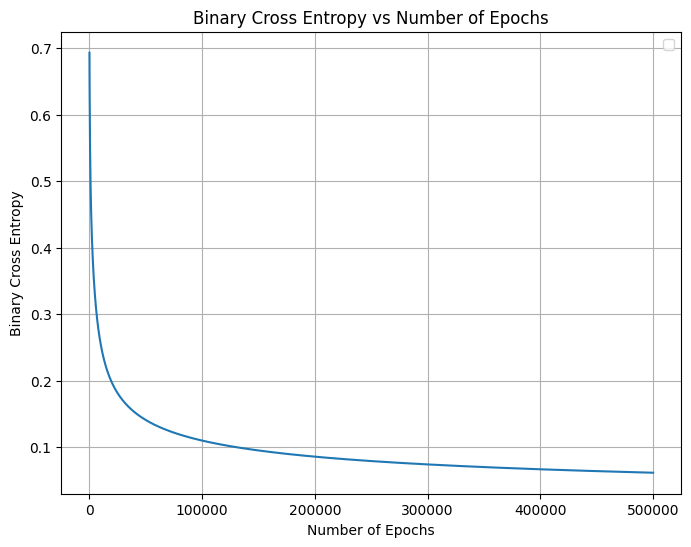

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,epochs + 1 ),history['err_arr'])

plt.xlabel("Number of Epochs")
plt.ylabel("Binary Cross Entropy")
plt.title("Binary Cross Entropy vs Number of Epochs")
plt.grid(True)
plt.legend()

plt.show()

# Print final values of hyperparameter,  m1,m2, m3, and c

In [ ]:
print("\n Final model parameters:")
print(f" Gradient for m1 = {m1}")
print(f" Gradient for m2 = {m2}")
print(f" Gradient for m3 = {m3}")
print(f" Y - intercept (c) = {c}")


 Final model parameters:
 Gradient for m1 = -29.65699703001371
 Gradient for m2 = 64.16737845620422
 Gradient for m3 = -47.0155215925632
 Y - intercept (c) = 34.98782285106433


# Scatter plot of Y vs Y_pred

/tmp/ipykernel_5166/2304969575.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


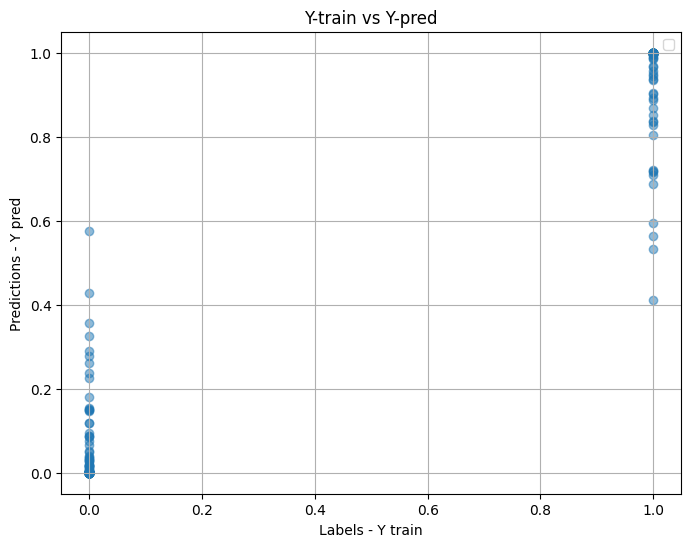

In [ ]:
plt.figure(figsize=(8, 6))
Y_pred = sigmoid(X.dot(w))
plt.scatter(Y, Y_pred, alpha=0.5)
plt.xlabel("Labels - Y train")
plt.ylabel("Predictions - Y pred")
plt.title("Y-train vs Y-pred")
plt.grid(True)
plt.legend()

plt.show()